In [1]:
import yaml
import argparse
import logging
from types import SimpleNamespace
import os
from pathlib import Path
import csv
import sys
import math
import numpy as np
import pandas as pd
import time
import joblib
import json 
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
# sys.path.append('/Users/yiqin/Documents/PythonProjects/GraspDataProcessing/src')
# sys.path.append('D:\\PythonPrograms\\GraspDataProcessing\\src')
sys.path.append('D:\\PythonProjects\\GraspDataProcessing\\src')
import graspdataprocessing as gdp


In [2]:
def load_config(config_path):
    """加载YAML配置文件"""
    with open(config_path, 'r') as f:
        config = yaml.safe_load(f)
    return SimpleNamespace(**config)

def update_config(config_path, updates):
    """更新YAML配置文件
    
    Args:
        config_path: 配置文件路径
        updates: 要更新的键值对字典
    """
    with open(config_path, 'r') as f:
        config = yaml.safe_load(f)
    
    # 更新配置值
    config.update(updates)
    
    with open(config_path, 'w') as f:
        yaml.dump(config, f, default_flow_style=False, sort_keys=False)

def setup_logging(config):
    """配置日志系统"""
    os.makedirs("logs", exist_ok=True)
    logging.basicConfig(
        level=logging.INFO,
        format='%(asctime)s - %(levelname)s - %(message)s',
        handlers=[
            logging.FileHandler("logs/machine_learning_training.log"),
            logging.StreamHandler()
        ]
    )
    return logging.getLogger(__name__)

def setup_directories(root_path):
    """创建必要的目录结构"""
    root_path = Path(root_path)
    directories = ["models", "descripotors", "descripotors_stay", "test_data", "roc_curves", "results"]
    
    for directory in directories:
        (root_path / directory).mkdir(parents=True, exist_ok=True)
    
    return root_path

def initialize_results_file(result_csv_path, logger):
    """初始化结果CSV文件"""
    try:
        if not result_csv_path.exists():
            with result_csv_path.open(mode="w", newline="") as file:
                writer = csv.writer(file)
                writer.writerow([
                    'training_time', 'eval_time', 'abinitio_time', 'all_time',
                    'f1', 'roc_auc', 'accuracy', 'precision', 'recall',
                    'Es', 'abimport_csfnum', 'MLimport_csfnum', 'MLsampling_ratio', 'next_itr_num',
                    'weight', 'f1_train', 'roc_auc_train', 'accuracy_train', 'precision_train', 'recall_train'
                ])
    except IOError as e:
        logger.error(f"无法创建结果文件 {result_csv_path}: {str(e)}")
        raise

def validate_initial_files(config, root_path, logger):
    """验证初始文件的存在和有效性"""
    # 验证初始CSFs文件
    initial_csfs_path = root_path / config.target_pool_file
    try:
        if not initial_csfs_path.is_file():
            logger.error(f"初始CSFs文件无效或不存在: {initial_csfs_path}")
            raise FileNotFoundError(f"初始CSFs文件无效或不存在: {initial_csfs_path}")
        logger.info(f"成功加载初始CSFs文件: {initial_csfs_path}")
    except PermissionError as e:
        logger.error(f"无权限访问CSFs文件: {initial_csfs_path}")
        raise
    except Exception as e:
        logger.error(f"加载CSFs文件时发生未知错误: {str(e)}")
        raise
    
    return initial_csfs_path

def check_configuration_coupling(config, energy_level_data_pd, logger):
    """检查组态耦合是否正确"""
    cal_configuration_set = set(energy_level_data_pd['configuration'])
    
    if set(config.spetral_term).issubset(cal_configuration_set):
        logger.info(f"cal_loop {config.cal_loop_num} 组态耦合正确")
        return True
    else:
        logger.error(f"cal_loop {config.cal_loop_num} 组态耦合错误")
        return False
    
def check_convergence(config, sum_num_list, logger):
    """检查收敛性"""
    # 这里需要Es_term的历史数据，暂时先跳过收敛检查
    # 在实际使用中，需要维护能量项的历史记录
    logger.info("收敛检查功能需要能量历史数据，当前跳过")
    return False

In [3]:
config_file = 'config.yaml'  # 配置文件的路径
config = load_config(config_file)

In [4]:
"""主程序逻辑"""
config.file_name = f'{config.conf}_{config.cal_loop_num}'
logger = setup_logging(config)
logger.info("机器学习训练程序启动")
execution_time = time.time()

# 设置目录结构
root_path = setup_directories(config.root_path)

# 初始化结果文件
result_csv_path = root_path / 'results/results.csv'
initialize_results_file(result_csv_path, logger)

# 验证初始文件
validate_initial_files(config, root_path, logger)

logger.info(f"初始比例: {config.initial_ratio}")
logger.info(f"光谱项: {config.spetral_term}")

2025-06-09 10:04:20,082 - INFO - 机器学习训练程序启动
2025-06-09 10:04:20,084 - INFO - 成功加载初始CSFs文件: D:\PythonProjects\as3_odd4\cv4odd1as3_odd4.c
2025-06-09 10:04:20,084 - INFO - 初始比例: 0.09
2025-06-09 10:04:20,084 - INFO - 光谱项: ['5s(2).4d(10)1S0_1S.5p(6).6s(2).4f(7)8S0_8S.5d_9D', '5s(2).4d(10)1S0_1S.5p(6).6s(2).4f(7)8S0_8S.5d_7D']


In [7]:
try:
    # 加载数据文件
    energy_level_data_pd, rmix_file_data, raw_csf_data, cal_csfs_data = load_data_files(config)
    
    # 检查组态耦合
    cal_result = check_configuration_coupling(config, energy_level_data_pd, logger)
    
    # 初始化索引
    indices_temp = list(range(raw_csf_data.CSFs_block_length[0]))
    sum_num_list = []

except Exception as e:
        logger.error(f"程序执行过程中发生错误: {str(e)}")
        raise

Data file D:\PythonProjects\as3_odd4\cv4odd1as3_odd4_1\cv4odd1as3_odd4_1.level loaded.
file D:\PythonProjects\as3_odd4\cv4odd1as3_odd4_1\cv4odd1as3_odd4_1.level loaded
data file type: level data
energy levels data has been written into LEVEL/cv4odd1as3_odd4_1.level_level.csv csv file
Data file D:\PythonProjects\as3_odd4\cv4odd1as3_odd4_1\cv4odd1as3_odd4_1.m loaded.
data file type: rmcdhf mix_coefficient_data
g92mix: G92MIX
 nblock = 1,       ncftot =   385600,          nw =  41,            nelec =   64


100%|██████████| 1/1 [00:00<00:00, 1000.55it/s]

cycle jblock = 1
 Block no. = 1, 2J+1 = 9, Parity = -1, No. of eigenvalues = 2, No. of CSFs = 385600

    Energy levels for ...
Rydberg constant is  109737.31568508

---------------------------------------------
 No Pos  J  Parity   Energy Total    Levels
                      (a.u.)         (cm^-1)
---------------------------------------------

  1  1   4   +    -11274.7413433        0.00
  2  0   4   +    -11274.7204780     4579.40


Data file D:\PythonProjects\as3_odd4\cv4odd1as3_odd4_1\cv4odd1as3_odd4_1.c loaded.


2025-06-09 10:04:49,237 - INFO - cal_loop 1 组态耦合正确


In [8]:
if cal_result:
    # 记录能量信息
    for level in rmix_file_data.level_List:
        logger.info(f"迭代能量：{level}")
    logger.info("耦合正确")
    logger.info("************************************************")

2025-06-09 10:04:50,859 - INFO - 迭代能量：-11274.741343317686
2025-06-09 10:04:50,860 - INFO - 迭代能量：-11274.720478024547
2025-06-09 10:04:50,860 - INFO - 耦合正确
2025-06-09 10:04:50,861 - INFO - ************************************************


In [9]:
logger.info("开始增强特征提取")
cut_off_csfs_indices_dict = gdp.batch_asfs_mix_square_above_threshold(
        rmix_file_data, float(config.cutoff_value)
    )

2025-06-09 10:04:52,827 - INFO - 开始增强特征提取


In [21]:
config

namespace(atom='GdI',
          conf='cv4odd1as3_odd4',
          spetral_term=['5s(2).4d(10)1S0_1S.5p(6).6s(2).4f(7)8S0_8S.5d_9D',
                        '5s(2).4d(10)1S0_1S.5p(6).6s(2).4f(7)8S0_8S.5d_7D'],
          cal_loop_num=1,
          difference=0,
          cutoff_value='1e-9',
          initial_ratio=0.09,
          expansion_ratio=2,
          target_pool_file='cv4odd1as3_odd4.c',
          target_pool_file_pkl='cv4odd1as3_odd4_csfs_info.pkl',
          root_path='D:\\PythonProjects\\as3_odd4',
          selected_csfs_file='mJ-1-90chosenas3_odd4.c',
          model_params={'n_estimators': 1000,
                        'class_weight': {0: 1, 1: 3},
                        'random_state': 42},
          file_name='cv4odd1as3_odd4_1')

In [23]:
config_file = 'config.yaml'  # 配置文件的路径
configasdfas = load_config(config_file)

配置验证通过: cutoff_value=1e-09, initial_ratio=0.09


In [24]:
configasdfas

namespace(atom='GdI',
          conf='cv4odd1as3_odd4',
          spetral_term=['5s(2).4d(10)1S0_1S.5p(6).6s(2).4f(7)8S0_8S.5d_9D',
                        '5s(2).4d(10)1S0_1S.5p(6).6s(2).4f(7)8S0_8S.5d_7D'],
          cal_loop_num=1,
          difference=0,
          cutoff_value=1e-09,
          initial_ratio=0.09,
          expansion_ratio=2,
          target_pool_file='cv4odd1as3_odd4.c',
          root_path=WindowsPath('D:/PythonProjects/as3_odd4'),
          selected_csfs_file='mJ-1-90chosenas3_odd4.c',
          model_params={'n_estimators': 1000,
                        'class_weight': {0: 1.0, 1: 3.0},
                        'random_state': 42})

In [10]:
raw_csfs_descriptors = gdp.load_descriptors("D:\\PythonProjects\\as3_odd4\\cv4odd1as3_odd4_data.npy")

Descriptors loaded from: D:\PythonProjects\as3_odd4\cv4odd1as3_odd4_data.npy


In [11]:
chosen_csfs_indices_dict = gdp.csfs_index_load('D:\\PythonProjects\\as3_odd4\\cv4odd1as3_odd4_1\\cv4odd1as3_odd4_1_chosen_indices.pkl')

In [12]:
# 获取选择的CSFs索引
selected_indices = chosen_csfs_indices_dict[0]

# 直接从raw_csfs_descriptors中提取对应的描述符
selected_csfs_descriptors = raw_csfs_descriptors[selected_indices]

In [16]:
selected_csfs_descriptors

array([[2., 0., 0., ..., 0., 0., 8.],
       [2., 0., 0., ..., 0., 0., 8.],
       [2., 0., 0., ..., 0., 0., 8.],
       ...,
       [2., 0., 0., ..., 0., 0., 8.],
       [2., 0., 0., ..., 0., 0., 8.],
       [2., 0., 0., ..., 0., 0., 8.]], dtype=float32)

In [13]:
csf_mix_coeff_squared_sum = np.sum(rmix_file_data.mix_coefficient_List[0]**2, axis=0) 


In [14]:
csf_mix_coeff_descriptors = np.zeros(selected_csfs_descriptors.shape[0], dtype=bool)


In [41]:
csf_mix_coeff_squared_sum.shape

(385600,)

In [42]:
selected_csfs_descriptors.shape

(385600, 87)

In [15]:
csf_mix_coeff_squared_sum

array([1.50986129e-01, 1.41364757e-01, 8.22232348e-02, ...,
       4.17132180e-13, 7.34551145e-13, 1.35580956e-13])

In [16]:
csf_mix_coeff_descriptors[csf_mix_coeff_squared_sum >= np.float64(config.cutoff_value)] = True

In [47]:
csf_mix_coeff_descriptors

array([ True,  True,  True, ..., False, False, False], shape=(385600,))

In [17]:
caled_csfs_descriptors = np.column_stack([selected_csfs_descriptors, csf_mix_coeff_descriptors])

In [18]:
cal_path = root_path / f'{config.conf}_{config.cal_loop_num}'

gdp.save_descriptors(caled_csfs_descriptors, f'{cal_path}/{config.conf}_{config.cal_loop_num}', 'npy')

Descriptors saved to: D:\PythonProjects\as3_odd4\cv4odd1as3_odd4_1/cv4odd1as3_odd4_1.npy


In [19]:
logger.info("             特征提取完成")
logger.info("             数据预处理")

X = caled_csfs_descriptors[:, :-1]
y = caled_csfs_descriptors[:, -1]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_resampled, y_resampled = X_train, y_train
model = gdp.ANNClassifier(input_size=X_train.shape[1], hidden_size=128)


2025-06-09 10:05:11,622 - INFO -              特征提取完成
2025-06-09 10:05:11,623 - INFO -              数据预处理


2025-06-09 10:05:14,168 - INFO -              训练模型
2025-06-09 10:05:29,144 - INFO - Epoch [50/150], Loss: 0.024245
2025-06-09 10:05:44,180 - INFO - Epoch [100/150], Loss: 0.023109
2025-06-09 10:05:59,262 - INFO - Epoch [150/150], Loss: 0.022474
2025-06-09 10:05:59,262 - INFO -              预测与评估


(385600,)


ValueError: x and y must be the same size

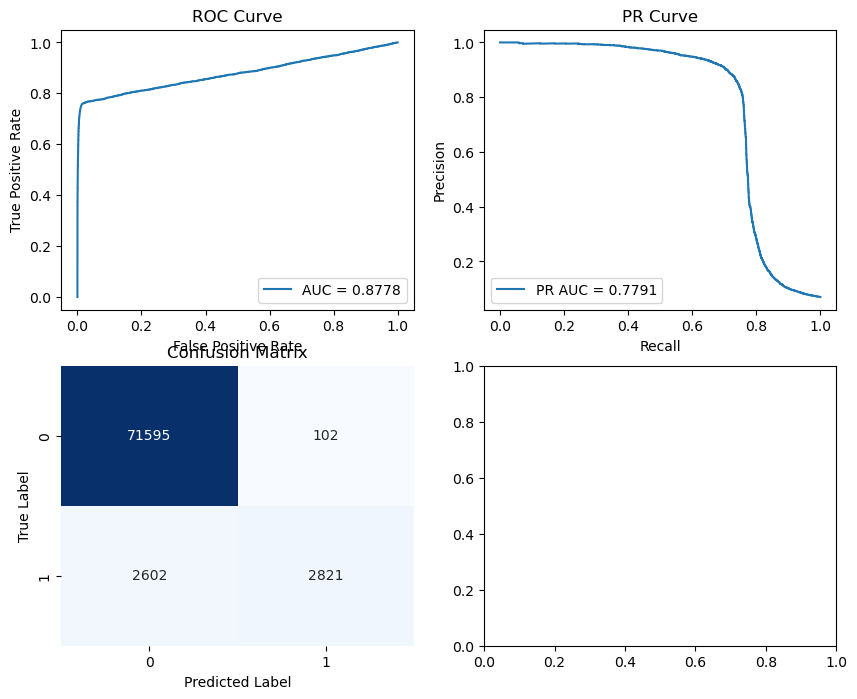

In [20]:
# Model training
logger.info("             训练模型")
start_time = time.time()
model.fit(X_resampled, y_resampled)
training_time = time.time() - start_time

# Model evaluation
logger.info("             预测与评估")
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]
y_pred_train = model.predict(X_train)
y_proba_train = model.predict_proba(X_train)[:, 1]
y_proba_all = model.predict_proba(X)
print(y_proba_all[:, 1].shape)
roc_auc, pr_auc = gdp.ANNClassifier.plot_curve(rmix_file_data.mix_coefficient_List[0], y_proba_all, y_test, y_proba, root_path.joinpath('roc_auc.png'))
f1, roc_auc, accuracy, precision, recall = gdp.ANNClassifier.model_evaluation(y_test, y_pred, y_proba)
logger.info ("测试集预测结果:")
logger.info (f"AUC:{roc_auc}, pr_auc:{pr_auc}, f1:{f1}, accuracy:{accuracy}, precision:{precision}, recall:{recall}")
# Overfitting and underfitting monitoring
f1_train, roc_auc_train, accuracy_train, precision_train, recall_train = gdp.ANNClassifier.model_evaluation(y_train, y_pred_train, y_proba_train)
logger.info (f"训练集预测结果:")
logger.info (f"AUC:{roc_auc_train}, f1:{f1_train}, accuracy:{accuracy_train}, precision:{precision_train}, recall:{recall_train}")

In [ ]:
def train_enhanced_model(features, config, logger):
    """使用增强特征训练模型"""
    if gdp is None:
        raise ImportError("graspdataprocessing 模块未正确导入")
    
    logger.info("开始训练增强模型")
    
    # 准备训练数据
    X = features['feature_vector'].reshape(1, -1)  # 全局特征
    y = features['labels']  # CSF重要性标签
    
    # 为了训练，我们需要创建样本
    # 使用重要CSF索引创建正样本，随机选择负样本
    important_indices = features['important_indices']
    
    # 创建平衡的训练集
    n_important = len(important_indices)
    n_total = len(y)
    
    # 选择所有重要CSF和等量的不重要CSF
    negative_indices = np.where(y == 0)[0]
    selected_negative = np.random.choice(
        negative_indices, 
        size=min(n_important * 2, len(negative_indices)), 
        replace=False
    )
    
    # 合并正负样本索引
    train_indices = np.concatenate([important_indices, selected_negative])
    X_train = np.tile(X, (len(train_indices), 1))  # 重复全局特征
    y_train = y[train_indices]
    
    # 划分训练测试集
    X_train, X_test, y_train, y_test = train_test_split(
        X_train, y_train, test_size=0.2, random_state=42
    )
    
    # 初始化或加载模型
    models_dir = Path("models")
    models_dir.mkdir(exist_ok=True)
    
    if config.cal_loop_num == 1:
        model = RandomForestClassifier(
            class_weight={0:1, 1:3}, n_estimators=1000, verbose=True, n_jobs=-1
        )
    else:
        model_path = models_dir / f"{config.conf}_{config.cal_loop_num-1}.pkl"
        if model_path.exists():
            model = joblib.load(model_path)
        else:
            model = RandomForestClassifier(
                class_weight={0:1, 1:3}, n_estimators=1000, verbose=True, n_jobs=-1
            )
    
    # 设置权重
    weight = [1, max(1, 12 - 2*config.cal_loop_num)]
    logger.info(f"权重: {weight}")
    
    # 训练模型
    start_time = time.time()
    model.fit(X_train, y_train)
    training_time = time.time() - start_time
    
    # 保存模型
    model_file = models_dir / f"{config.file_name}.pkl"
    joblib.dump(model, model_file)
    
    # 评估模型
    y_pred = model.predict(X_test)
    accuracy = np.mean(y_pred == y_test)
    logger.info(f"模型训练完成，测试准确率: {accuracy:.4f}")
    
    return model, training_time, weight